<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: Clustering por Gaussian Mixture Models</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clustering basado en GMM. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales: leea y responda los siguientes incisos</b>
<ul>
</ul>
</div>

**1.** Utilice GMM para la segmentación de clientes en el análisis de la cesta de la compra del siguiente dataset `customer_shopping.csv`. Emplee GMM para agrupar a los clientes según su comportamiento de compra. Una vez agrupados, podrá crear promociones dirigidas y recomendaciones personalizadas para cada segmento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Cargamos el dataset
df_shopping = pd.read_csv('data/customer_shopping.csv')
df_shopping.head()

,Customer,Bread,Milk,Eggs,Beer,Chips
0,c001,12,10,8,0,1
1,c002,10,8,7,1,0
2,c003,11,9,6,0,1
3,c004,1,2,1,10,8
4,c005,0,1,2,12,10


In [2]:
import os
import warnings

# Silencia la advertencia de OpenMP en Windows
os.environ["OMP_NUM_THREADS"] = "1"

# Ignora los avisos de tipo UserWarning
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# Cargamos el dataset sanitario
df_health = pd.read_csv('data/healthcare_dataset.csv')
df_health.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
# Para usar columnas categóricas junto a numéricas las codificamos con One-Hot Encoding
selected_cols = ['Age', 'Billing Amount', 'Gender', 'Medical Condition']
df_health_sub = df_health[selected_cols].dropna()

# Aplicamos One-Hot Encoding a las variables categóricas
df_health_encoded = pd.get_dummies(df_health_sub, columns=['Gender', 'Medical Condition'], drop_first=True)

# Escalamiento de las características resultantes
scaler_health = StandardScaler()
X_health_scaled = scaler_health.fit_transform(df_health_encoded)

In [5]:
# Evaluación con BIC/AIC
bics_health = []
for n in range(1, 8):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_health_scaled)
    bics_health.append(gmm.bic(X_health_scaled))

# Entrenamos el modelo con 3 clusters
k_health = 3
gmm_health = GaussianMixture(n_components=k_health, random_state=42)
df_health_sub['Cluster'] = gmm_health.fit_predict(X_health_scaled)
df_health_sub.head()

,Age,Billing Amount,Gender,Medical Condition,Cluster
0,30,18856.281306,Male,Cancer,0
1,62,33643.327287,Male,Obesity,0
2,76,27955.096079,Female,Obesity,0
3,28,37909.782410,Female,Diabetes,1
4,43,14238.317814,Female,Cancer,0


In [6]:
# Datos del nuevo paciente
nuevo_paciente = pd.DataFrame([{
    'Age': 65,
    'Billing Amount': 25000.0,
    'Gender': 'Male',
    'Medical Condition': 'Diabetes'
}])

# Procesamos sus variables igual que en el entrenamiento
nuevo_paciente_encoded = pd.get_dummies(nuevo_paciente, columns=['Gender', 'Medical Condition'])
nuevo_paciente_encoded = nuevo_paciente_encoded.reindex(columns=df_health_encoded.columns, fill_value=0)

# Escalar y predecir
nuevo_paciente_scaled = scaler_health.transform(nuevo_paciente_encoded)
cluster_paciente = gmm_health.predict(nuevo_paciente_scaled)[0]
print(f"El nuevo paciente fue asignado al Cluster Sanitario: {cluster_paciente}")


El nuevo paciente fue asignado al Cluster Sanitario: 1


In [7]:
# Mantenemos exactamente el mismo orden y columnas del dataframe original
nuevo_cliente_dict = {
    'Customer': ['c006'],
    'Bread': [5],
    'Milk': [2],
    'Eggs': [1],
    'Beer': [12],
    'Chips': [8]
}

nuevo_cliente_df = pd.DataFrame(nuevo_cliente_dict)
display(nuevo_cliente_df)

,Customer,Bread,Milk,Eggs,Beer,Chips
0,c006,5,2,1,12,8


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# 1. Definimos las columnas y ajustamos el escalador
features_shopping = ['Bread', 'Milk', 'Eggs', 'Beer', 'Chips']
scaler_shopping = StandardScaler()
X_shopping_scaled = scaler_shopping.fit_transform(df_shopping[features_shopping])

# 2. Re-entrenamos el modelo GMM
gmm_shopping = GaussianMixture(n_components=3, random_state=42)
gmm_shopping.fit(X_shopping_scaled)

# 3. Escalamos y predecimos para el nuevo cliente
nuevo_cliente_scaled = scaler_shopping.transform(nuevo_cliente_df[features_shopping])
cluster_pred = gmm_shopping.predict(nuevo_cliente_scaled)[0]

print(f"El nuevo cliente pertenece al Cluster: {cluster_pred}")

El nuevo cliente pertenece al Cluster: 1


In [9]:
# Recomendación personalizada según el cluster obtenido
if cluster_pred == 0:
    print("Recomendación: Enviar cupones para productos de la canasta básica como Pan y Leche.")
elif cluster_pred == 1:
    print("Recomendación: Promoción especial de fin de semana: Combo Cerveza + Botanas (Chips).")
else:
    print("Recomendación: Descuento exclusivo en abarrotes y productos para el desayuno (Huevos y Leche).")

Recomendación: Promoción especial de fin de semana: Combo Cerveza + Botanas (Chips).


**2.-**  Obtenga un modelo de clustering para el dataset `healthcare_dataset.csv` para obtener una agrupación de pacientes sanitarios mediante GMM: Los hospitales a menudo necesitan agrupar a pacientes con características similares para: identificar pacientes de alto riesgo, personalizar planes de tratamiento, optimizar la asignación de recursos y mejorar la gestión sanitaria.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Cargamos el dataset sanitario
df_health = pd.read_csv('data/healthcare_dataset.csv')
df_health.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [11]:
# Para combinar columnas numéricas y categóricas, aplicamos One-Hot Encoding a las categóricas
selected_cols = ['Age', 'Billing Amount', 'Gender', 'Medical Condition']
df_health_sub = df_health[selected_cols].dropna()

# One-Hot Encoding
df_health_encoded = pd.get_dummies(df_health_sub, columns=['Gender', 'Medical Condition'], drop_first=True)

# Escalamiento de todas las variables resultantes
scaler_health = StandardScaler()
X_health_scaled = scaler_health.fit_transform(df_health_encoded)

In [12]:
# Evaluamos de 1 a 6 componentes con el criterio BIC para elegir K óptimo
bics_health = []
for n in range(1, 7):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_health_scaled)
    bics_health.append(gmm.bic(X_health_scaled))

# Entrenamos con 3 clusters y creamos la columna 'Cluster'
gmm_health = GaussianMixture(n_components=3, random_state=42)
df_health_sub['Cluster'] = gmm_health.fit_predict(X_health_scaled)

df_health_sub.head()


,Age,Billing Amount,Gender,Medical Condition,Cluster
0,30,18856.281306,Male,Cancer,0
1,62,33643.327287,Male,Obesity,0
2,76,27955.096079,Female,Obesity,0
3,28,37909.782410,Female,Diabetes,1
4,43,14238.317814,Female,Cancer,0


In [13]:
# Definimos el nuevo paciente con datos de ejemplo
nuevo_paciente = pd.DataFrame([{
    'Age': 65,
    'Billing Amount': 25000.0,
    'Gender': 'Male',
    'Medical Condition': 'Diabetes'
}])

# Convertimos con One-Hot Encoding manteniendo exactamente las mismas columnas
nuevo_paciente_encoded = pd.get_dummies(nuevo_paciente, columns=['Gender', 'Medical Condition'])
nuevo_paciente_encoded = nuevo_paciente_encoded.reindex(columns=df_health_encoded.columns, fill_value=0)

# Escalar y predecir su cluster
nuevo_paciente_scaled = scaler_health.transform(nuevo_paciente_encoded)
cluster_paciente = gmm_health.predict(nuevo_paciente_scaled)[0]

print(f"El nuevo paciente fue asignado al Cluster Sanitario: {cluster_paciente}")


El nuevo paciente fue asignado al Cluster Sanitario: 1


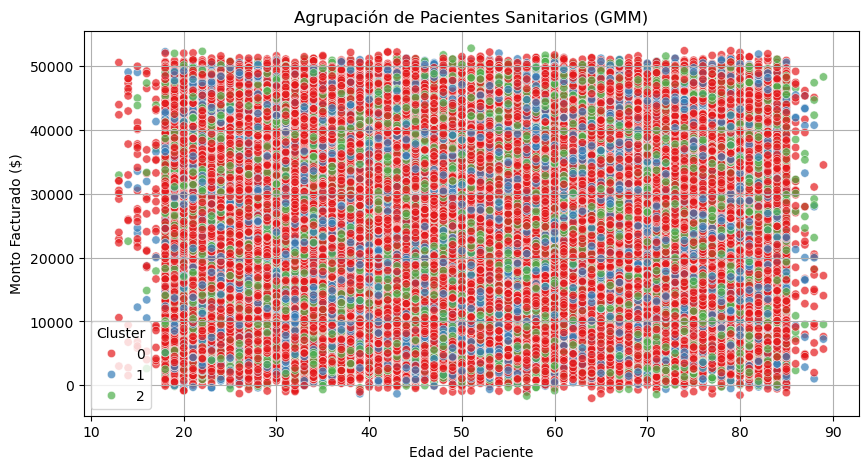

In [14]:
# Gráfica de dispersión de Edad vs Monto Facturado por Cluster
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_health_sub, 
    x='Age', 
    y='Billing Amount', 
    hue='Cluster', 
    palette='Set1', 
    alpha=0.7
)
plt.title('Agrupación de Pacientes Sanitarios (GMM)')
plt.xlabel('Edad del Paciente')
plt.ylabel('Monto Facturado ($)')
plt.grid(True)
plt.show()